<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Benchmark 2 - TPeanuts vs nuSQuIDS Performance
---

This notebook is the nuSQuIDS-side counterpart of
`benchmark1_tpeanuts_vs_peanuts.ipynb`: same methodology, same helper
functions, same benchmark structure — with the external reference swapped
from legacy `peanuts` (NumPy/Numba) to `nuSQuIDS` (C++/pybind11), and one
new section (§8) for atmospheric propagation, which legacy `peanuts` does
not implement at all.

The purpose is performance characterization, not precision validation.
Precision and bit-level agreement with nuSQuIDS are studied in the
`notebooks/validation/nusquids/` notebooks; here the same physical inputs
are used so timing differences can be interpreted as implementation and
batching effects.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: methodology, nuSQuIDS reference, single-point solar choice |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** — paths, parameters, shared objects and helpers |
| [3](#3.-Vacuum-Propagation) | **Vacuum Propagation** |
| [4](#4.-Solar-Single-Point-Propagation) | **Solar Single-Point Propagation** |
| [5](#5.-Earth-Propagation) | **Earth Propagation** |
| [6](#6.-Integrated-Probabilities) | **Integrated Probabilities** |
| [7](#7.-Solar-to-Detector-Chain) | **Solar-to-Detector Chain** |
| [8](#8.-Atmospheric-Propagation) | **Atmospheric Propagation** (new — no legacy-peanuts equivalent) |
| [9](#9.-GPU-Benchmark) | **GPU Benchmark** (tpeanuts CPU vs GPU only — nuSQuIDS has no GPU backend) |
| [10](#10.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 Performance Benchmarking Strategy

Same convention as `benchmark1_tpeanuts_vs_peanuts.ipynb`: each stage is
timed after warm-up calls, repeated several times, and the reported
speedup is

$$S = \frac{t_{\rm nuSQuIDS}}{t_{\rm tpeanuts}},$$

so that $S>1$ means `tpeanuts` is faster than nuSQuIDS.

### 0.2 nuSQuIDS Reference: also a scalar, per-point API

Unlike legacy `peanuts` (NumPy/Numba, JIT-compiled scalar loops), nuSQuIDS
is a C++ library exposed through pybind11. Its Python API has no batched
"many energies at once" entry point either: every call
(`nsq.nuSQUIDS(3, ...)`, mixing-angle setters, `Set_Body`/`Set_Track`,
`EvolveState`) constructs and evolves **one** solver object per
(energy, angle) point. The comparison here is therefore the same shape as
in `benchmark1`: batched `tpeanuts` tensor evaluation vs. a Python loop of
scalar external-library calls — except nuSQuIDS's per-call cost (full
solver construction + ODE integration, no JIT reuse across calls) is
typically *larger* than legacy `peanuts`'s. Grid sizes in this notebook are
therefore kept smaller than in `benchmark1` to keep total runtime
reasonable (see §2.2).

### 0.3 Solar Section: single-point, not source-averaged

`nusquids2_solar.ipynb` already validates the expensive, source-averaged
comparison (`solar_probability_state` vs. a manual nuSQuIDS quadrature over many production
radii). Repeating that quadrature here would make the nuSQuIDS solar
timing scale with the number of quadrature points chosen for precision,
not with the energy-grid size being benchmarked, which would confound the
scaling study. §4 therefore benchmarks the same **single production
radius** comparison as `nusquids2_solar.ipynb` §4 (`Tei` vs
`probability_solar_point`), which is the fair, apples-to-apples unit of
work for a timing study.

### 0.4 Solar-to-Detector Chain: shared mass weights

For the same reason, §7 (and §6) build the incoherent solar mass weights
**once**, with `tpeanuts`'s own `solar_probability_mass` (source-averaged,
using the real B16 production profile), and time only the *Earth
propagation* step for both backends from that shared input — exactly the
convention already established in
`nusquids5_SolarNeutrino_EarthDetection.ipynb` §5. This isolates the Earth
propagation cost being benchmarked from the (unrelated, backend-specific)
cost of solar production averaging.

### 0.5 Atmospheric Propagation (new)

Legacy `peanuts` has no atmosphere module at all (confirmed in the
pipeline/architecture review earlier in this project), so
`benchmark1_tpeanuts_vs_peanuts.ipynb` could not include it. `tpeanuts`'s
`medium.atmosphere` and nuSQuIDS's `EarthAtm`-based `probability_atmosphere`
both exist, so §8 benchmarks that stage directly, mirroring the Earth
section's structure.

---

**References**

- L. Wolfenstein, *Neutrino oscillations in matter*, Phys. Rev. D **17**, 2369 (1978).
- S. P. Mikheyev and A. Yu. Smirnov, *Resonance amplification of oscillations in matter*, Sov. J. Nucl. Phys. **42**, 913 (1985).
- I. Esteban et al., *NuFIT 5.2 global analysis of three-flavour neutrino oscillations*, JHEP **09**, 178 (2022).
- C. A. Argüelles, J. Salvado & C. N. Weaver, *nuSQuIDS: A toolbox for neutrino propagation*, Comput. Phys. Commun. **277**, 108346 (2022).
- A. Paszke et al., *PyTorch: An Imperative Style, High-Performance Deep Learning Library*, NeurIPS (2019).

## 1. Libraries

In [11]:
from __future__ import annotations

import gc
import math
import time
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import torch
from IPython.display import display
%matplotlib inline

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy, FLAVOUR_NAMES, FLAVOUR_INDEX
from tpeanuts.util.context import RuntimeContext

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.common.probability import probability_incoherent
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state, earth_probability_state_analytical
from tpeanuts.medium.solar.probability import solar_probability_state, solar_probability_mass, Tei
from tpeanuts.medium.solar.profile import SolarParameters, SolarProfile
from tpeanuts.medium.vacuum.probability import vacuum_probability_transition
from tpeanuts.medium.atmosphere.probability import atmosphere_probability_transition
from tpeanuts.medium.atmosphere.profile import AtmosphereParameters

from tpeanuts.external.nusquids.core import (
    NuSQuIDSConfig,
    is_available as nusquids_is_available,
    probability_vacuum as nusquids_probability_vacuum,
    probability_solar_point as nusquids_probability_solar_point,
    probability_earth_massbasis as nusquids_probability_earth_massbasis,
    transition_matrix_earth_mass_to_flavour as nusquids_transition_matrix_earth,
    probability_atmosphere as nusquids_probability_atmosphere,
)

print(f"Torch version : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"nuSQuIDS available: {nusquids_is_available()}")
from tpeanuts.util.math import numpy_trapezoid


Torch version : 2.12.0+cu126
CUDA available: True
nuSQuIDS available: True


## 2. Paths and Configuration

This section resolves the project paths, creates the benchmark output
directory, and fixes the physical and numerical configuration used in the
timing study.

### 2.1 Paths

Outputs are saved under `benchmark/nusquids/` — a dedicated subdirectory,
so this notebook's CSVs/figures never collide with
`benchmark1_tpeanuts_vs_peanuts.ipynb`'s own `benchmark/` files.

In [12]:
config = load_notebook_config()

PACKAGE_DIR = config.package_dir
OUTPUT_DIR  = config.output_dir("benchmark", "nusquids")

print(f"PACKAGE_DIR = {PACKAGE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

PACKAGE_DIR = /mnt/g/Mi unidad/03.Codigo/034.TFM.UV/Tpeanuts
Output directory: /mnt/v/output/benchmark/nusquids


### 2.2 Configuration

| Parameter | Value | Description |
|-----------|-------|-------------|
| Oscillation preset | `_SM_NUFIT52_NO` | Three-flavour NuFIT 5.2 NO benchmark point |
| Vacuum baseline | 1300 km | Long-baseline reference distance |
| Solar production radius | $r_0=0.10\,R_\odot$ | Fixed single point for §4 (see §0.3) |
| Solar source (chain) | `8B` | Source used for the §6/§7 shared mass weights |
| Earth profile | bundled `even_power_electron.csv` | Five-layer even-power propagation profile |
| Atmosphere profile | `nusquids_earthatm` density source | Same density convention as nuSQuIDS's `EarthAtm` |
| Energy-grid sizes | 2 to 32 | Scaling axis for all workflows (smaller than `benchmark1`, see §0.2) |
| Nadir/cos-zenith-grid sizes | 2 to 32 | Scaling axis for Earth/atmosphere-dependent workflows |
| Timing repeats/warmups | 3 / 1 | nuSQuIDS has no JIT to warm up, unlike legacy Numba |

In [13]:
DEVICE = config.device
DTYPE  = config.dtype
SHOW_PLOTS = config.show_plots
GPU_DEVICE = torch.device("cuda", 0) if torch.cuda.is_available() else None
NSQ_AVAILABLE = nusquids_is_available()

context     = RuntimeContext.resolve(DEVICE, DTYPE)
oscillation = PropagationConfig.oscillation_parameters_from_preset("_SM_NUFIT52_NO", antinu=False, context=context)
pmns        = oscillation.pmns
THETA12  = float(pmns.params.theta12.detach().cpu())
THETA13  = float(pmns.params.theta13.detach().cpu())
THETA23  = float(pmns.params.theta23.detach().cpu())
DELTA_CP = float(pmns.params.delta.detach().cpu())
DM21_EV2 = float(oscillation.mass_spectrum.DeltamSq21.detach().cpu())
DM3L_EV2 = float(oscillation.mass_spectrum.DeltamSq3l.detach().cpu())

NSQ_CFG = NuSQuIDSConfig(
    theta12=THETA12, theta13=THETA13, theta23=THETA23, delta_cp=DELTA_CP,
    DeltamSq21=DM21_EV2, DeltamSq3l=DM3L_EV2,
    rel_error=1.0e-7, abs_error=1.0e-10, h_max_km=None,
)

# Solar propagation integrates a *coherent* state across the full solar
# radius (~7e5 km) -- a much longer, more tightly-varying-density path than
# vacuum/Earth/atmosphere. At NSQ_CFG's tolerance this took ~11s per single
# call in testing; loosened to keep §4 tractable at full grid size while
# still being a fair (if less numerically strict) timing comparison -- §4
# is a performance benchmark, not a precision study (see nusquids2_solar.ipynb
# for the precision-grade comparison).
NSQ_CFG_SOLAR = NuSQuIDSConfig(
    theta12=THETA12, theta13=THETA13, theta23=THETA23, delta_cp=DELTA_CP,
    DeltamSq21=DM21_EV2, DeltamSq3l=DM3L_EV2,
    rel_error=1.0e-4, abs_error=1.0e-6, h_max_km=None,
)

ENERGY_GRID_SIZES = [ 4, 8, 16, 32, 64,128,256]
NADIR_GRID_SIZES  = [ 4, 8, 16, 32, 64,128,256]

TIMING_REPEATS = 3
TIMING_WARMUPS = 1

EARTH_DEPTH_M          = 0.0
SOLAR_DETECTOR_DEPTH_M = 1000.0
SOLAR_SOURCE           = "8B"
SOLAR_R0               = 0.10          # r / R_sun, fixed single production point (see §0.3)
VACUUM_BASELINE_KM     = 1300.0
ATM_H_PROD_KM          = 22.0
ATM_DEPTH_KM           = 0.0

MASS_WEIGHTS    = torch.tensor([0.20, 0.30, 0.50], dtype=DTYPE, device=DEVICE)
MASS_WEIGHTS_NP = np.array([0.20, 0.30, 0.50], dtype=np.float64)

print("Performance benchmark parameters loaded.")
print(f"  TIMING_REPEATS = {TIMING_REPEATS},  TIMING_WARMUPS = {TIMING_WARMUPS}")
print(f"  ENERGY_GRID_SIZES = {ENERGY_GRID_SIZES}")
print(f"  NADIR_GRID_SIZES  = {NADIR_GRID_SIZES}")

Performance benchmark parameters loaded.
  TIMING_REPEATS = 3,  TIMING_WARMUPS = 1
  ENERGY_GRID_SIZES = [4, 8, 16, 32, 64, 128, 256]
  NADIR_GRID_SIZES  = [4, 8, 16, 32, 64, 128, 256]


### 2.3 Shared Objects

Builds the `tpeanuts` Earth and solar profile objects once, reused by
every timed call below (never rebuilt inside a timing loop).

In [14]:
earth_profile_t = EarthProfile(
    params=EarthParameters(
        profile_perturbative_kwargs={
            "density_file": str(config.earth_density_file),
            "tabulated_density": False,
        },
    ),
    context=context,
)
solar_profile = SolarProfile.default(context=context)
atm_params = AtmosphereParameters(
    atmosphere_density_source="nusquids_earthatm",
    nsteps=600,
    matter=True,
)
print("Shared Earth, solar, and atmosphere profile objects built.")

Shared Earth, solar, and atmosphere profile objects built.


### 2.4 Local Helpers

Same benchmark mechanics as `benchmark1_tpeanuts_vs_peanuts.ipynb`
(`timed_call`, `benchmark_pair`, plotting helpers), renamed from
`*_legacy_*` to `*_nusquids_*`, plus the nuSQuIDS-side computation
wrappers for each physics stage.

In [15]:
from tpeanuts.notebooks.benchmark.benchmark_helpers import *

configure_benchmark_helpers(globals(), backend="nusquids")
print("Benchmark helpers imported from notebooks/benchmark/benchmark_helpers.py.")


Benchmark helpers imported from notebooks/benchmark/benchmark_helpers.py.


## 3. Vacuum Propagation

Benchmarks vacuum flavour-transition probabilities. The `tpeanuts` path
uses the batched `vacuum_probability_transition` API in one call; the nuSQuIDS path
loops over the three initial flavours (one solver construction each) to
build the same $3\times3$ matrix, mirroring `legacy_vacuum_matrix` in
`benchmark1`.

**Expected results:** the speedup curve should reveal where tensor
batching overtakes the per-flavour nuSQuIDS solver construction loop.

vacuum probabilities               | NE=   4 | Neta=None | t=1.1885e-03s+/-1.3e-04 | nsq=9.9930e-04s | x0.84
vacuum probabilities               | NE=   8 | Neta=None | t=1.2009e-03s+/-2.6e-04 | nsq=1.6185e-03s | x1.35
vacuum probabilities               | NE=  16 | Neta=None | t=1.2091e-03s+/-3.1e-04 | nsq=2.8171e-03s | x2.33
vacuum probabilities               | NE=  32 | Neta=None | t=1.2440e-03s+/-7.7e-04 | nsq=5.6037e-03s | x4.50
vacuum probabilities               | NE=  64 | Neta=None | t=1.5157e-03s+/-1.6e-04 | nsq=1.0214e-02s | x6.74
vacuum probabilities               | NE= 128 | Neta=None | t=1.5620e-03s+/-9.0e-04 | nsq=2.0795e-02s | x13.31
vacuum probabilities               | NE= 256 | Neta=None | t=1.5674e-03s+/-4.5e-04 | nsq=3.9951e-02s | x25.49


,section,n_energy,n_nadir,tpeanuts_best_s,nusquids_best_s,tpeanuts_mean_s,nusquids_mean_s,tpeanuts_std_s,nusquids_std_s,speedup_nusquids_over_tpeanuts
0,vacuum probabilities,4,None,0.001188,0.000999,0.001299,0.001021,0.000132,0.000016,0.840808
1,vacuum probabilities,8,None,0.001201,0.001618,0.001412,0.001680,0.000261,0.000054,1.347739
2,vacuum probabilities,16,None,0.001209,0.002817,0.001472,0.002871,0.000308,0.000053,2.329915
3,vacuum probabilities,32,None,0.001244,0.005604,0.001792,0.005808,0.000771,0.000160,4.504582
4,vacuum probabilities,64,None,0.001516,0.010214,0.001741,0.010350,0.000160,0.000130,6.738867
5,vacuum probabilities,128,None,0.001562,0.020795,0.002537,0.023351,0.000900,0.001845,13.312996
6,vacuum probabilities,256,None,0.001567,0.039951,0.001894,0.040394,0.000453,0.000439,25.488516


Saved: /mnt/v/output/benchmark/nusquids/vacuum_probability_timing.csv


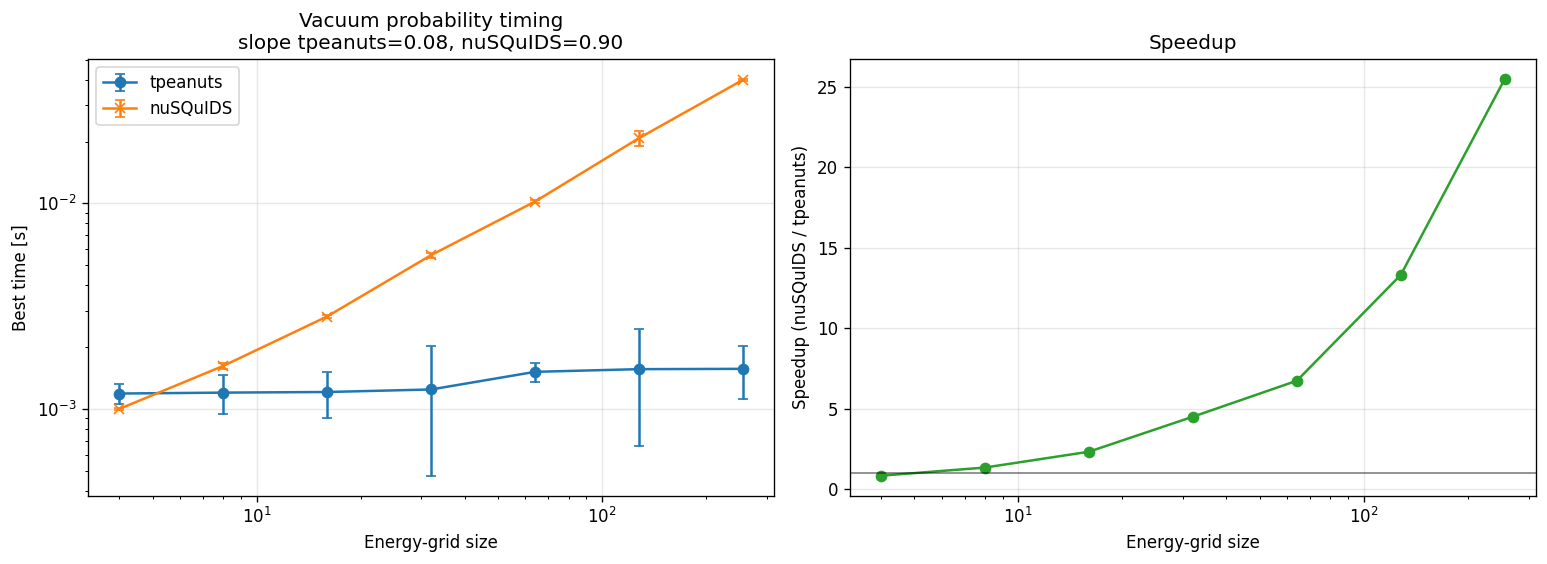

/mnt/v/output/benchmark/nusquids/vacuum_probability_timing.png


In [16]:
vacuum_probability_records = []
for ne in ENERGY_GRID_SIZES:
    E = energy_grid(ne, solar=False)
    vacuum_probability_records.append(benchmark_pair(
        "vacuum probabilities", ne, None,
        lambda E=E: vacuum_probability_transition(oscillation, E, VACUUM_BASELINE_KM, context=context),
        lambda E=E: nusquids_vacuum_matrix(E, VACUUM_BASELINE_KM),
    ))
vacuum_probability_df = pd.DataFrame(vacuum_probability_records)
display(vacuum_probability_df)
save_results(vacuum_probability_df, "vacuum_probability_timing")
plot_energy_scaling(vacuum_probability_df, "Vacuum probability timing", "vacuum_probability_timing.png")

vacuum flux                        | NE=   4 | Neta=None | t=1.2943e-03s+/-1.2e-04 | nsq=1.0518e-03s | x0.81
vacuum flux                        | NE=   8 | Neta=None | t=1.3490e-03s+/-1.9e-04 | nsq=1.6887e-03s | x1.25
vacuum flux                        | NE=  16 | Neta=None | t=1.2701e-03s+/-6.4e-04 | nsq=2.8990e-03s | x2.28
vacuum flux                        | NE=  32 | Neta=None | t=1.3552e-03s+/-3.7e-04 | nsq=5.4455e-03s | x4.02
vacuum flux                        | NE=  64 | Neta=None | t=1.5106e-03s+/-6.2e-04 | nsq=1.0504e-02s | x6.95
vacuum flux                        | NE= 128 | Neta=None | t=1.7694e-03s+/-3.2e-04 | nsq=2.0901e-02s | x11.81
vacuum flux                        | NE= 256 | Neta=None | t=1.7218e-03s+/-3.0e-04 | nsq=4.0696e-02s | x23.64


,section,n_energy,n_nadir,tpeanuts_best_s,nusquids_best_s,tpeanuts_mean_s,nusquids_mean_s,tpeanuts_std_s,nusquids_std_s,speedup_nusquids_over_tpeanuts
0,vacuum flux,4,None,0.001294,0.001052,0.001447,0.001062,0.000117,0.000014,0.812640
1,vacuum flux,8,None,0.001349,0.001689,0.001504,0.001746,0.000187,0.000079,1.251816
2,vacuum flux,16,None,0.001270,0.002899,0.001762,0.002954,0.000644,0.000043,2.282497
3,vacuum flux,32,None,0.001355,0.005445,0.001664,0.005831,0.000372,0.000471,4.018226
4,vacuum flux,64,None,0.001511,0.010504,0.002141,0.010750,0.000618,0.000243,6.953462
5,vacuum flux,128,None,0.001769,0.020901,0.002012,0.022506,0.000323,0.001139,11.812705
6,vacuum flux,256,None,0.001722,0.040696,0.002078,0.041776,0.000304,0.001286,23.635498


Saved: /mnt/v/output/benchmark/nusquids/vacuum_flux_timing.csv


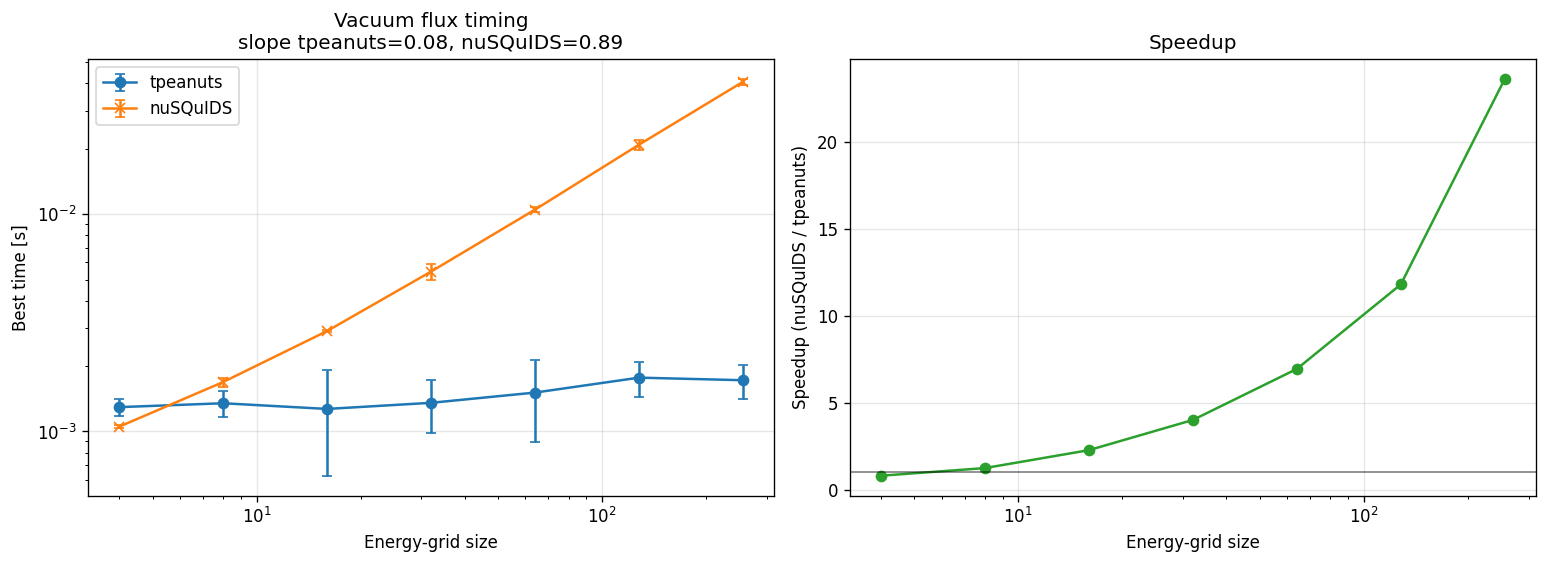

/mnt/v/output/benchmark/nusquids/vacuum_flux_timing.png


In [17]:
vacuum_flux_records = []
for ne in ENERGY_GRID_SIZES:
    E = energy_grid(ne, solar=False)
    flux_t = synthetic_flux(E)
    flux_n = to_numpy(flux_t)
    vacuum_flux_records.append(benchmark_pair(
        "vacuum flux", ne, None,
        lambda E=E, ft=flux_t: probability_incoherent(
            vacuum_probability_transition(oscillation, E, VACUUM_BASELINE_KM, context=context), ft),
        lambda E=E, fn=flux_n: np.einsum("eba,ea->eb", nusquids_vacuum_matrix(E, VACUUM_BASELINE_KM), fn),
    ))
vacuum_flux_df = pd.DataFrame(vacuum_flux_records)
display(vacuum_flux_df)
save_results(vacuum_flux_df, "vacuum_flux_timing")
plot_energy_scaling(vacuum_flux_df, "Vacuum flux timing", "vacuum_flux_timing.png")

## 4. Solar Single-Point Propagation

Benchmarks the adiabatic matter-mixing weights at one fixed solar
production radius (see §0.3). `tpeanuts` uses `Tei` in one batched call
over the energy grid; nuSQuIDS loops `probability_solar_point` per energy.

**Expected results:** timing should increase with grid size, and the
vectorized `Tei` evaluation should reduce Python-loop/solver-construction
overhead relative to nuSQuIDS.

solar single-point (Tei)           | NE=   4 | Neta=None | t=1.6942e-03s+/-4.0e-05 | nsq=1.5560e+00s | x918.45
solar single-point (Tei)           | NE=   8 | Neta=None | t=1.7496e-03s+/-4.7e-04 | nsq=2.3765e+00s | x1358.29
solar single-point (Tei)           | NE=  16 | Neta=None | t=1.7821e-03s+/-1.5e-04 | nsq=4.1193e+00s | x2311.46
solar single-point (Tei)           | NE=  32 | Neta=None | t=1.7373e-03s+/-3.6e-04 | nsq=7.7823e+00s | x4479.53
solar single-point (Tei)           | NE=  64 | Neta=None | t=2.1866e-03s+/-5.7e-05 | nsq=1.5093e+01s | x6902.59
solar single-point (Tei)           | NE= 128 | Neta=None | t=1.7678e-03s+/-3.7e-04 | nsq=2.9656e+01s | x16775.92
solar single-point (Tei)           | NE= 256 | Neta=None | t=1.8670e-03s+/-1.9e-04 | nsq=5.9706e+01s | x31979.64


,section,n_energy,n_nadir,tpeanuts_best_s,nusquids_best_s,tpeanuts_mean_s,nusquids_mean_s,tpeanuts_std_s,nusquids_std_s,speedup_nusquids_over_tpeanuts
0,solar single-point (Tei),4,None,0.001694,1.556041,0.001750,1.577374,0.000040,0.027479,918.451540
1,solar single-point (Tei),8,None,0.001750,2.376465,0.002092,2.414230,0.000472,0.044094,1358.290753
2,solar single-point (Tei),16,None,0.001782,4.119250,0.001917,4.194375,0.000153,0.065254,2311.458461
3,solar single-point (Tei),32,None,0.001737,7.782280,0.002027,7.829043,0.000355,0.037921,4479.525857
4,solar single-point (Tei),64,None,0.002187,15.093209,0.002263,15.148741,0.000057,0.043762,6902.592511
5,solar single-point (Tei),128,None,0.001768,29.656466,0.002241,29.766417,0.000374,0.111621,16775.916955
6,solar single-point (Tei),256,None,0.001867,59.705985,0.002084,59.724846,0.000188,0.013836,31979.638485


Saved: /mnt/v/output/benchmark/nusquids/solar_probability_timing.csv


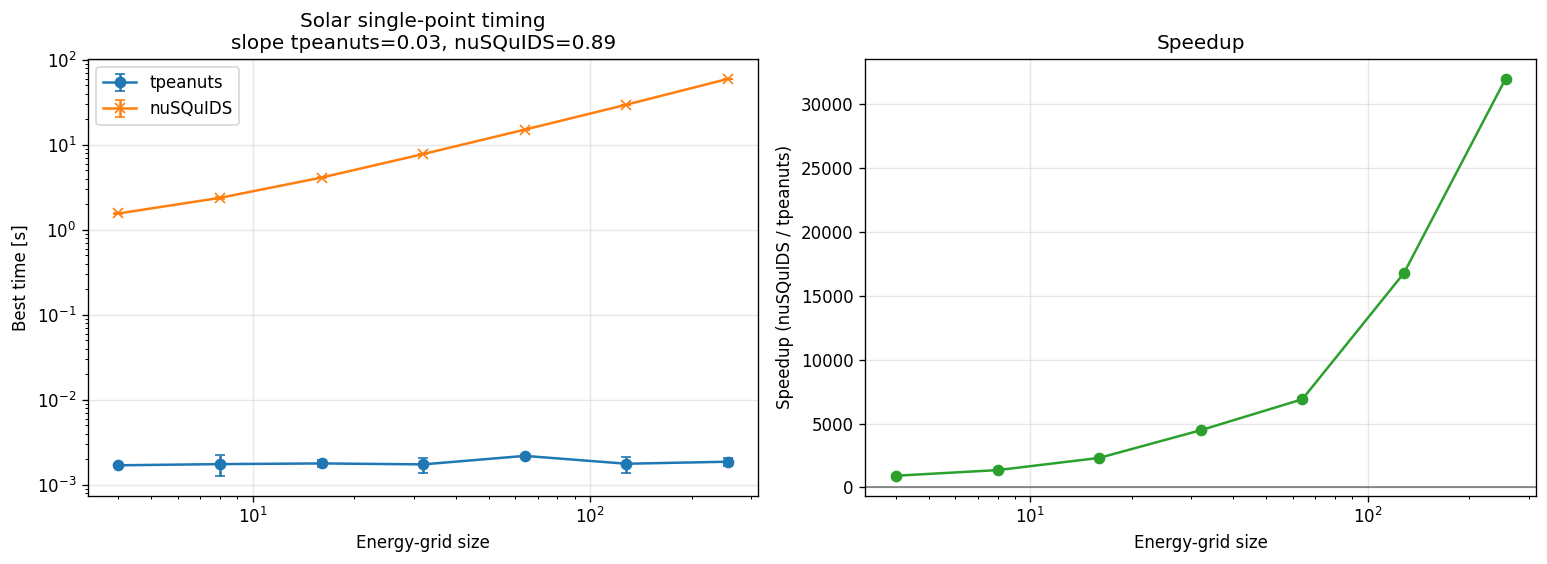

/mnt/v/output/benchmark/nusquids/solar_probability_timing.png


In [18]:
solar_probability_records = []
for ne in ENERGY_GRID_SIZES:
    E = energy_grid(ne, solar=True)
    solar_probability_records.append(benchmark_pair(
        "solar single-point (Tei)", ne, None,
        lambda E=E: tpeanuts_solar_point(E),
        lambda E=E: nusquids_solar_point(E),
    ))
solar_probability_df = pd.DataFrame(solar_probability_records)
display(solar_probability_df)
save_results(solar_probability_df, "solar_probability_timing")
plot_energy_scaling(solar_probability_df, "Solar single-point timing", "solar_probability_timing.png")

solar single-point flux            | NE=   4 | Neta=None | t=1.7533e-03s+/-5.9e-04 | nsq=1.5295e+00s | x872.35
solar single-point flux            | NE=   8 | Neta=None | t=1.6106e-03s+/-2.8e-04 | nsq=2.3330e+00s | x1448.50
solar single-point flux            | NE=  16 | Neta=None | t=1.5610e-03s+/-7.3e-04 | nsq=4.0894e+00s | x2619.70
solar single-point flux            | NE=  32 | Neta=None | t=1.7832e-03s+/-1.9e-04 | nsq=7.6659e+00s | x4298.96
solar single-point flux            | NE=  64 | Neta=None | t=1.7669e-03s+/-5.2e-04 | nsq=1.4973e+01s | x8474.27
solar single-point flux            | NE= 128 | Neta=None | t=1.7485e-03s+/-3.2e-04 | nsq=2.9689e+01s | x16979.55
solar single-point flux            | NE= 256 | Neta=None | t=1.6220e-03s+/-5.4e-04 | nsq=5.9120e+01s | x36448.58


,section,n_energy,n_nadir,tpeanuts_best_s,nusquids_best_s,tpeanuts_mean_s,nusquids_mean_s,tpeanuts_std_s,nusquids_std_s,speedup_nusquids_over_tpeanuts
0,solar single-point flux,4,None,0.001753,1.529496,0.002317,1.544390,0.000590,0.011552,872.352590
1,solar single-point flux,8,None,0.001611,2.332958,0.001890,2.351790,0.000278,0.020829,1448.502600
2,solar single-point flux,16,None,0.001561,4.089355,0.002108,4.124637,0.000732,0.035779,2619.701976
3,solar single-point flux,32,None,0.001783,7.665908,0.001976,7.927881,0.000194,0.278634,4298.961659
4,solar single-point flux,64,None,0.001767,14.973188,0.002148,14.988634,0.000524,0.016397,8474.270162
5,solar single-point flux,128,None,0.001749,29.688768,0.002013,29.823464,0.000315,0.188602,16979.554501
6,solar single-point flux,256,None,0.001622,59.119589,0.002075,59.251347,0.000535,0.111737,36448.575395


Saved: /mnt/v/output/benchmark/nusquids/solar_flux_timing.csv


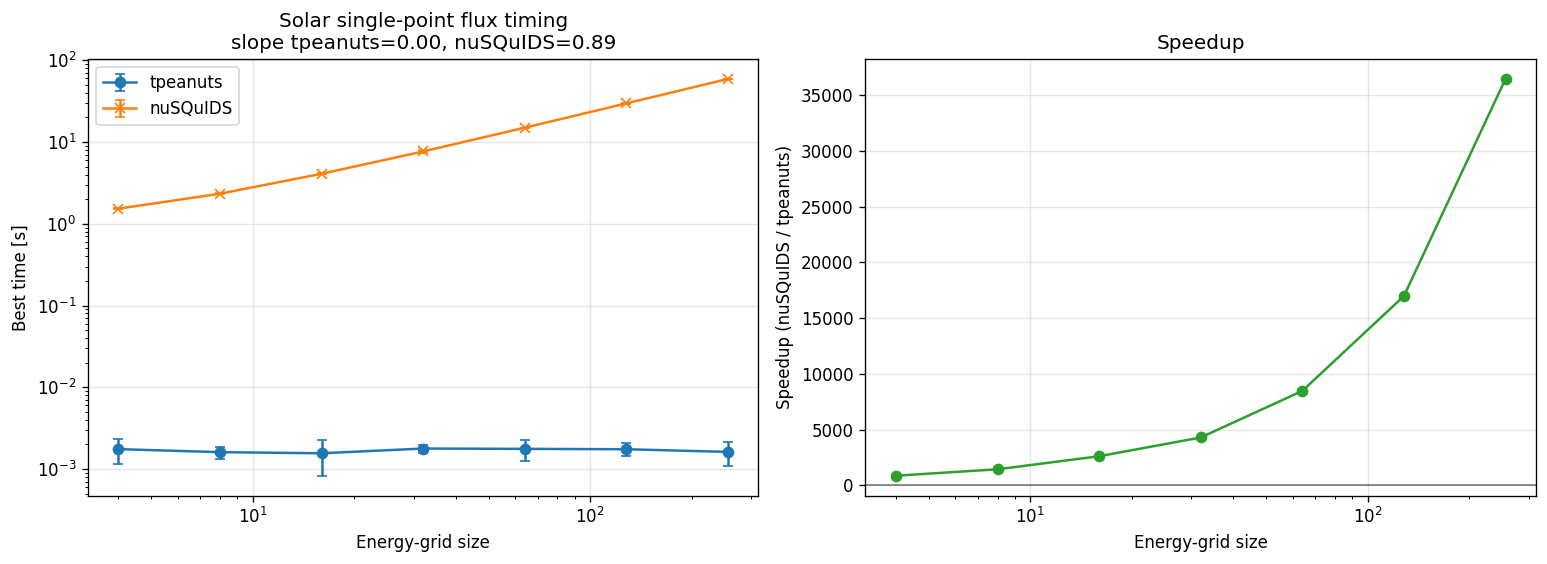

/mnt/v/output/benchmark/nusquids/solar_flux_timing.png


In [19]:
solar_flux_records = []
for ne in ENERGY_GRID_SIZES:
    E = energy_grid(ne, solar=True)
    spectrum_t = solar_source_spectrum(E)
    spectrum_n = to_numpy(spectrum_t)
    solar_flux_records.append(benchmark_pair(
        "solar single-point flux", ne, None,
        lambda E=E, st=spectrum_t: tpeanuts_solar_point(E) * st[:, None],
        lambda E=E, sn=spectrum_n: nusquids_solar_point(E) * sn[:, None],
    ))
solar_flux_df = pd.DataFrame(solar_flux_records)
display(solar_flux_df)
save_results(solar_flux_df, "solar_flux_timing")
plot_energy_scaling(solar_flux_df, "Solar single-point flux timing", "solar_flux_timing.png")

## 5. Earth Propagation

Benchmarks Earth matter regeneration over two-dimensional energy-nadir
grids, for the fixed incoherent state `MASS_WEIGHTS`. `tpeanuts` uses the
batched analytical evolutor; nuSQuIDS loops
`probability_earth_massbasis` (itself built on the `Earth.Track`
baseline-length fix from §5 of `nusquids5_SolarNeutrino_EarthDetection.ipynb`).

**Expected results:** speedup should generally grow with the
two-dimensional grid size.

In [20]:
earth_probability_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d   = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        earth_probability_records.append(benchmark_pair(
            "earth probabilities", ne, neta,
            lambda E=E_1d, eta=eta_1d: torch_pearth_probability(
                MASS_WEIGHTS, E[:, None], eta[None, :], EARTH_DEPTH_M, massbasis=True),
            lambda E=E_1d, eta=eta_1d: nusquids_earth_matrix(MASS_WEIGHTS_NP, E, eta),
        ))
earth_probability_df = pd.DataFrame(earth_probability_records)
display(earth_probability_df)
save_results(earth_probability_df, "earth_probability_timing")
plot_heatmap(earth_probability_df, "Earth probability speedup (LogNorm)",
              "earth_probability_speedup.png")
plot_speedup_cross_sections(earth_probability_df, "Earth probability speedup cross sections",
                              "earth_probability_speedup_cross_sections.png")

earth probabilities                | NE=   4 | Neta=   4 | t=1.2202e-02s+/-1.1e-03 | nsq=1.6942e+00s | x138.85
earth probabilities                | NE=   4 | Neta=   8 | t=1.2710e-02s+/-4.8e-04 | nsq=3.1024e+00s | x244.09
earth probabilities                | NE=   4 | Neta=  16 | t=1.3517e-02s+/-8.6e-04 | nsq=5.7912e+00s | x428.44
earth probabilities                | NE=   4 | Neta=  32 | t=1.5326e-02s+/-1.3e-03 | nsq=1.1422e+01s | x745.28
earth probabilities                | NE=   4 | Neta=  64 | t=1.9713e-02s+/-2.2e-03 | nsq=2.2522e+01s | x1142.51
earth probabilities                | NE=   4 | Neta= 128 | t=2.3037e-02s+/-2.2e-03 | nsq=4.4878e+01s | x1948.07
earth probabilities                | NE=   4 | Neta= 256 | t=3.9097e-02s+/-2.0e-04 | nsq=8.9949e+01s | x2300.65
earth probabilities                | NE=   8 | Neta=   4 | t=1.2542e-02s+/-6.0e-04 | nsq=2.4379e+00s | x194.38
earth probabilities                | NE=   8 | Neta=   8 | t=1.3146e-02s+/-1.0e-03 | nsq=4.4555e+00s | x338.9

KeyboardInterrupt: 

### 5.2 Flux Timing

Builds the mass-to-flavour transition matrix (three mass eigenstates) and
applies it to a synthetic flux vector. On the nuSQuIDS side this uses
`transition_matrix_earth_mass_to_flavour` directly (three solver calls per
grid point, one per mass eigenstate), matching the `tpeanuts` per-basis-
vector loop.

**Expected results:** three times the per-point cost of §5.1 on both
sides, so the relative speedup should be similar.

In [ ]:
earth_flux_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d   = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        flux   = synthetic_flux(E_1d)
        earth_flux_records.append(benchmark_pair(
            "earth flux", ne, neta,
            lambda E=E_1d, eta=eta_1d, fl=flux: _tpeanuts_earth_flux(E, eta, fl),
            lambda E=E_1d, eta=eta_1d, fl=to_numpy(flux): _nusquids_earth_flux(E, eta, fl),
        ))
earth_flux_df = pd.DataFrame(earth_flux_records)
display(earth_flux_df)
save_results(earth_flux_df, "earth_flux_timing")
plot_heatmap(earth_flux_df, "Earth flux speedup (LogNorm)", "earth_flux_speedup.png")
plot_speedup_cross_sections(earth_flux_df, "Earth flux speedup cross sections",
                              "earth_flux_speedup_cross_sections.png")

### 5.3 Analytical vs Numerical Earth Method (tpeanuts-internal)

Same diagnostic as `benchmark1` §5.3 — this does not involve nuSQuIDS at
all, it compares `tpeanuts`'s own perturbative-analytical and
medium-independent-numerical Earth evolutors. Included here for parallel
structure and because it now reflects the `return_history` optimization
applied to `earth_probability_state_numerical` earlier in this project.

**Expected results:** analytical propagation should usually be faster than
numerical propagation at these grid sizes.

In [ ]:
EARTH_NUMERICAL_STEPS = 160
EARTH_ODE_METHOD = "midpoint"
configure_benchmark_helpers(globals(), backend="nusquids")

earth_method_records = []
for ne in [8, 16, 32]:
    for neta in [8, 16, 32]:
        E_1d   = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        t_ana, _, _ = timed_call(lambda E=E_1d, eta=eta_1d: torch_pearth_probability(
            MASS_WEIGHTS, E[:, None], eta[None, :], EARTH_DEPTH_M, massbasis=True))
        t_num, _, _ = timed_call(lambda E=E_1d, eta=eta_1d: _tpeanuts_pearth_numerical(E, eta))
        earth_method_records.append({
            "n_energy": ne, "n_nadir": neta,
            "analytical_s": t_ana, "numerical_s": t_num,
            "speedup_ana_over_num": t_num / max(t_ana, 1e-15),
        })
earth_method_df = pd.DataFrame(earth_method_records)
display(earth_method_df)
save_results(earth_method_df, "earth_method_comparison")

## 6. Integrated Probabilities

A nadir-averaged probability with a uniform exposure weight — a timing
proxy for exposure-integrated observables (see §0.4 for the shared-weights
convention).

**Expected results:** timings should combine the Earth-grid cost with a
small integration overhead on both sides.

In [ ]:
integrated_probability_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d   = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        mass_t = tpeanuts_solar_mass(E_1d)
        mass_n = to_numpy(mass_t)
        integrated_probability_records.append(benchmark_pair(
            "integrated probabilities", ne, neta,
            lambda E=E_1d, eta=eta_1d: tpeanuts_integrated(E, eta, EARTH_DEPTH_M),
            lambda mn=mass_n, E=E_1d, eta=eta_1d: nusquids_integrated(mn, E, eta, EARTH_DEPTH_M),
        ))
integrated_probability_df = pd.DataFrame(integrated_probability_records)
display(integrated_probability_df)
save_results(integrated_probability_df, "integrated_probability_timing")
plot_heatmap(integrated_probability_df, "Integrated probability speedup (LogNorm)",
              "integrated_probability_speedup.png")
plot_speedup_cross_sections(integrated_probability_df, "Integrated probability speedup cross sections",
                              "integrated_probability_speedup_cross_sections.png")

## 7. Solar-to-Detector Chain

The full incoherent solar-to-detector structure: solar mass-basis
production (shared, computed once — see §0.4) followed by Earth matter
propagation at detector nadir angles.

**Expected results:** the most complete benchmark path; should show the
cumulative effect of batching the Earth-propagation stage.

In [ ]:
solar_detector_probability_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d   = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        mass_n = to_numpy(tpeanuts_solar_mass(E_1d))
        solar_detector_probability_records.append(benchmark_pair(
            "solar-detector probabilities", ne, neta,
            lambda E=E_1d, eta=eta_1d: tpeanuts_solar_detector_probabilities(E, eta),
            lambda mn=mass_n, E=E_1d, eta=eta_1d: nusquids_solar_detector_probabilities(mn, E, eta),
        ))
solar_detector_probability_df = pd.DataFrame(solar_detector_probability_records)
display(solar_detector_probability_df)
save_results(solar_detector_probability_df, "solar_detector_probability_timing")
plot_heatmap(solar_detector_probability_df, "Solar-detector probability speedup (LogNorm)",
              "solar_detector_probability_speedup.png")
plot_speedup_cross_sections(solar_detector_probability_df,
                              "Solar-detector probability speedup cross sections",
                              "solar_detector_probability_speedup_cross_sections.png")

In [ ]:
solar_detector_flux_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d      = energy_grid(ne, solar=True)
        eta_1d    = nadir_grid(neta)
        spectrum_t = solar_source_spectrum(E_1d)
        spectrum_n = to_numpy(spectrum_t)
        mass_n = to_numpy(tpeanuts_solar_mass(E_1d))
        solar_detector_flux_records.append(benchmark_pair(
            "solar-detector flux", ne, neta,
            lambda E=E_1d, eta=eta_1d, st=spectrum_t:
                tpeanuts_solar_detector_probabilities(E, eta) * st[:, None, None],
            lambda mn=mass_n, E=E_1d, eta=eta_1d, sn=spectrum_n:
                nusquids_solar_detector_probabilities(mn, E, eta) * sn[:, None, None],
        ))
solar_detector_flux_df = pd.DataFrame(solar_detector_flux_records)
display(solar_detector_flux_df)
save_results(solar_detector_flux_df, "solar_detector_flux_timing")
plot_heatmap(solar_detector_flux_df, "Solar-detector flux speedup (LogNorm)",
              "solar_detector_flux_speedup.png")
plot_speedup_cross_sections(solar_detector_flux_df,
                              "Solar-detector flux speedup cross sections",
                              "solar_detector_flux_speedup_cross_sections.png")

In [ ]:
solar_detector_integrated_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d   = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        mass_n = to_numpy(tpeanuts_solar_mass(E_1d))
        solar_detector_integrated_records.append(benchmark_pair(
            "solar-detector integrated", ne, neta,
            lambda E=E_1d, eta=eta_1d: tpeanuts_integrated(E, eta, SOLAR_DETECTOR_DEPTH_M),
            lambda mn=mass_n, E=E_1d, eta=eta_1d: nusquids_integrated(mn, E, eta, SOLAR_DETECTOR_DEPTH_M),
        ))
solar_detector_integrated_df = pd.DataFrame(solar_detector_integrated_records)
display(solar_detector_integrated_df)
save_results(solar_detector_integrated_df, "solar_detector_integrated_timing")
plot_heatmap(solar_detector_integrated_df,
              "Solar-detector integrated speedup (LogNorm)",
              "solar_detector_integrated_speedup.png")
plot_speedup_cross_sections(solar_detector_integrated_df,
                              "Solar-detector integrated speedup cross sections",
                              "solar_detector_integrated_speedup_cross_sections.png")

## 8. Atmospheric Propagation

New relative to `benchmark1_tpeanuts_vs_peanuts.ipynb` — legacy `peanuts`
has no atmosphere module. Benchmarks $P(\nu_\mu\to\nu_\beta)$ over
energy/$\cos\theta_z$ grids: `tpeanuts`'s `atmosphere_probability_transition` (one
batched call returns the full $3\times3$ matrix, from which the $\nu_\mu$
column is read) vs. nuSQuIDS's `probability_atmosphere` (one solver call
per grid point, `initial_flavour="numu"`, the standard atmospheric-neutrino
benchmark channel). Both sides use the same
`atmosphere_density_source="nusquids_earthatm"` density convention (§2.3),
so any residual timing difference is architectural, not from a mismatched
input density table.

**Expected results:** same qualitative scaling behaviour as the Earth
section (§5), since the underlying per-call cost structure (batched tensor
grid vs. scalar solver construction loop) is the same.

In [ ]:
atm_probability_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d = energy_grid(ne, solar=False) * 1.0e-3  # MeV -> GeV-scale energies, atmospheric range
        E_1d_MeV = E_1d * 1.0e3
        cosz_1d = np.linspace(0.1, 1.0, neta)

        def _tpeanuts_atm(E=E_1d_MeV, cosz=cosz_1d):
            return torch.stack([
                tpeanuts_atm_probability(torch.tensor(float(e), dtype=DTYPE, device=DEVICE), cz)
                for e in to_numpy(E) for cz in cosz
            ]).reshape(len(to_numpy(E)), len(cosz), 3)

        def _nusquids_atm(E=E_1d_MeV, cosz=cosz_1d):
            return nusquids_atm_matrix(E, cosz, initial_flavour="numu")

        atm_probability_records.append(benchmark_pair(
            "atmosphere probabilities", ne, neta, _tpeanuts_atm, _nusquids_atm,
        ))
atm_probability_df = pd.DataFrame(atm_probability_records)
display(atm_probability_df)
save_results(atm_probability_df, "atmosphere_probability_timing")
plot_heatmap(atm_probability_df, "Atmosphere probability speedup (LogNorm)",
              "atmosphere_probability_speedup.png")
plot_speedup_cross_sections(atm_probability_df, "Atmosphere probability speedup cross sections",
                              "atmosphere_probability_speedup_cross_sections.png")

## 9. GPU Benchmark (Conditional, tpeanuts only)

nuSQuIDS has no GPU backend, so this section — unlike every other one in
this notebook — does **not** compare against nuSQuIDS. It reuses
`benchmark1`'s CPU-vs-GPU comparison for the solar-to-detector probability
stage, kept for structural parallelism with `benchmark1` §8.

**Expected results:** on machines without CUDA the cell should skip
cleanly. See the earlier optimization investigation in this project for a
documented GPU performance cliff at large grid sizes on this project's
test GPU (GTX 1080 Ti) — not necessarily reproduced at the smaller grid
sizes used here.

In [ ]:
if not torch.cuda.is_available():
    print("No CUDA device — skipping GPU benchmark.")
else:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    _ = torch.zeros(1, device=GPU_DEVICE)
    torch.cuda.synchronize()

    gpu_records = []
    for ne in ENERGY_GRID_SIZES:
        for neta in NADIR_GRID_SIZES:
            E_1d   = energy_grid(ne, solar=True)
            eta_1d = nadir_grid(neta)

            def tpeanuts_cpu():
                return _tpeanuts_solar_detector_device(E_1d, eta_1d, DEVICE)

            def tpeanuts_gpu():
                E_g   = E_1d.to(GPU_DEVICE)
                eta_g = eta_1d.to(GPU_DEVICE)
                result = _tpeanuts_solar_detector_device(E_g, eta_g, GPU_DEVICE)
                torch.cuda.synchronize()
                return result

            t_cpu, _, _ = timed_call(tpeanuts_cpu)
            t_gpu, _, _ = timed_call(tpeanuts_gpu)
            speedup_gpu = t_cpu / max(t_gpu, 1e-15)
            gpu_records.append({
                "n_energy": ne, "n_nadir": neta,
                "cpu_s": t_cpu, "gpu_s": t_gpu,
                "speedup_gpu_over_cpu": speedup_gpu,
            })
            print(f"NE={ne:4d} | Neta={neta:4d} | CPU={t_cpu:.4e}s | GPU={t_gpu:.4e}s | x{speedup_gpu:.2f}")

    gpu_df = pd.DataFrame(gpu_records)
    display(gpu_df)
    save_results(gpu_df, "gpu_timing")

    pivot_gpu = gpu_df.pivot(index="n_nadir", columns="n_energy", values="speedup_gpu_over_cpu")
    vmax_gpu  = max(pivot_gpu.values.max(), 1.1)
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    im = ax.imshow(pivot_gpu.values, origin="lower", aspect="auto",
                   norm=mcolors.LogNorm(vmin=0.1, vmax=vmax_gpu), cmap="RdYlGn")
    ax.set_xticks(np.arange(len(pivot_gpu.columns))); ax.set_xticklabels(pivot_gpu.columns)
    ax.set_yticks(np.arange(len(pivot_gpu.index)));   ax.set_yticklabels(pivot_gpu.index)
    for r in range(pivot_gpu.values.shape[0]):
        for c in range(pivot_gpu.values.shape[1]):
            ax.text(c, r, f"{pivot_gpu.values[r,c]:.1f}x", ha="center", va="center", fontsize=8)
    ax.set_xlabel("Energy-grid size"); ax.set_ylabel("Nadir-grid size")
    ax.set_title("GPU / CPU speedup — solar-detector probabilities (tpeanuts only)")
    fig.colorbar(im, ax=ax, label="GPU speedup (log)")
    fig.tight_layout()
    save_and_show("gpu_speedup_heatmap.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 10. Summary

Combines all benchmark tables, stores a global CSV file, and produces
aggregate speedup figures for the largest grid sizes tested — the same
layout as `benchmark1_tpeanuts_vs_peanuts.ipynb` §9, now including the new
atmosphere section.

**Expected results:** the median-speedup plot should make the dominant
performance regimes visible across all eleven benchmarked workflows.

In [ ]:
all_timing_df = pd.concat([
    vacuum_probability_df, vacuum_flux_df,
    solar_probability_df,  solar_flux_df,
    earth_probability_df,  earth_flux_df,
    integrated_probability_df,
    solar_detector_probability_df, solar_detector_flux_df,
    solar_detector_integrated_df,
    atm_probability_df,
], ignore_index=True)
display(all_timing_df)
save_results(all_timing_df, "all_performance_timing")

summary = (
    all_timing_df.groupby("section", as_index=False)
    .agg(
        median_speedup=("speedup_nusquids_over_tpeanuts", "median"),
        min_speedup   =("speedup_nusquids_over_tpeanuts", "min"),
        max_speedup   =("speedup_nusquids_over_tpeanuts", "max"),
    )
    .sort_values("median_speedup", ascending=False)
)
display(summary)

fig, ax = plt.subplots(figsize=(11, 5.0))
xerr = np.array([
    summary["median_speedup"] - summary["min_speedup"],
    summary["max_speedup"]    - summary["median_speedup"],
])
colors = ["C2" if v > 1.0 else "C3" for v in summary["median_speedup"]]
ax.barh(summary["section"], summary["median_speedup"], xerr=xerr,
        color=colors, error_kw={"capsize": 4, "elinewidth": 1.2})
ax.axvline(1.0, color="black", lw=1.2, alpha=0.6)
ax.set_xlabel("Median speedup  (nuSQuIDS / tpeanuts)")
ax.set_title("Performance summary — median speedup with min/max error bars")
fig.tight_layout()
save_and_show("summary_median_speedup.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

largest_ne   = max(ENERGY_GRID_SIZES)
largest_neta = max(NADIR_GRID_SIZES)

large_rows = []
for df in [vacuum_probability_df, vacuum_flux_df, solar_probability_df, solar_flux_df,
           earth_probability_df, earth_flux_df, integrated_probability_df,
           solar_detector_probability_df, solar_detector_flux_df, solar_detector_integrated_df,
           atm_probability_df]:
    row = get_largest_timing_row(df, largest_ne, largest_neta)
    if row is not None:
        large_rows.append(row)
large_df = pd.DataFrame(large_rows).reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(13, 5.5))
x    = np.arange(len(large_df))
w    = 0.35
ax1.bar(x - w/2, large_df["tpeanuts_best_s"], width=w, label="tpeanuts", color="C0", alpha=0.85)
ax1.bar(x + w/2, large_df["nusquids_best_s"], width=w, label="nuSQuIDS", color="C1", alpha=0.85)
ax1.set_yscale("log")
ax1.set_ylabel("Best time [s]  (log scale)")
ax1.set_xticks(x)
ax1.set_xticklabels(large_df["section"], rotation=30, ha="right", fontsize=8)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(x, large_df["speedup_nusquids_over_tpeanuts"], "D-", color="C2", label="speedup", zorder=5)
ax2.axhline(1.0, color="gray", lw=0.8, ls="--")
ax2.set_ylabel("Speedup  (nuSQuIDS / tpeanuts)", color="C2")
ax2.tick_params(axis="y", labelcolor="C2")
ax2.legend(loc="upper right")

fig.suptitle(f"Absolute time + speedup at NE={largest_ne}, N(eta/cosz)={largest_neta}")
fig.tight_layout()
save_and_show("summary_time_and_speedup.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print("=" * 60)
print("BENCHMARK 2 -- TPeanuts vs nuSQuIDS Performance -- Summary")
print("=" * 60)
print(summary.to_string(index=False))